# CDTG Experiment: Confidence-Driven Trajectory Gate

## 1. Install Dependencies

In [1]:
!pip install -q transformers datasets bitsandbytes accelerate matplotlib seaborn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.4 MB/s eta 0:00:00


## 2. Imports

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from datasets import load_dataset
import re, warnings
warnings.filterwarnings('ignore')

print("✅ Imports done")

✅ Imports done


## 3. Load Model

In [3]:
MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)
model.eval()
print(f"✅ Model loaded on {model.device}")

config.json:   0%|          | 0.00/679 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.07k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

✅ Model loaded on cuda:0


## 4. Load GSM8K Dataset

In [4]:
# To avoid issues with dataset loading from Hugging Face Hub (e.g., rate limits or private datasets),
# it's recommended to log in with a Hugging Face token.
# You can get a token from https://huggingface.co/settings/tokens
# from huggingface_hub import login
# login(token='hf_YOUR_TOKEN_HERE') # Replace with your actual token

print("ℹ️ If you encounter dataset loading errors, uncomment the 'login' line above and replace 'hf_YOUR_TOKEN_HERE' with your Hugging Face token, then run this cell.")

ℹ️ If you encounter dataset loading errors, uncomment the 'login' line above and replace 'hf_YOUR_TOKEN_HERE' with your Hugging Face token, then run this cell.


In [6]:
dataset = load_dataset("openai/gsm8k", "main", split="test")
NUM_PROBLEMS = 30
problems = [dataset[i] for i in range(NUM_PROBLEMS)]
print(f"✅ Loaded {NUM_PROBLEMS} GSM8K problems")

README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

✅ Loaded 30 GSM8K problems


## 5. Helper Functions

In [7]:
def get_gt_answer(solution_text):
    """Extract ground truth answer from GSM8K solution string."""
    match = re.search(r'####\s*([\-\d,\.]+)', solution_text)
    if match:
        return match.group(1).replace(',', '').strip()
    return None

def extract_model_answer(text):
    """Extract final numerical answer from model output."""
    # Try #### format
    match = re.search(r'####\s*([\-\d,\.]+)', text)
    if match:
        return match.group(1).replace(',', '').strip()
    # Try boxed answer
    match = re.search(r'\\boxed\{([\-\d,\.]+)\}', text)
    if match:
        return match.group(1).replace(',', '').strip()
    # Last number in the text
    nums = re.findall(r'[\-]?\d+(?:,\d+)*(?:\.\d+)?', text)
    return nums[-1].replace(',', '') if nums else None

def segment_steps(token_ids, probs, tokenizer, min_tokens=4):
    """
    Group tokens into reasoning steps by splitting on newlines.
    Returns list of dicts with step text and mean confidence.
    """
    steps = []
    cur_ids, cur_probs = [], []

    for tid, p in zip(token_ids, probs):
        cur_ids.append(tid)
        cur_probs.append(p)
        decoded = tokenizer.decode([tid])
        if '\n' in decoded and len(cur_probs) >= min_tokens:
            steps.append({
                'text': tokenizer.decode(cur_ids, skip_special_tokens=True),
                'confidence': float(np.mean(cur_probs)),
                'min_prob': float(np.min(cur_probs)),
                'n_tokens': len(cur_probs)
            })
            cur_ids, cur_probs = [], []

    if len(cur_probs) >= min_tokens:
        steps.append({
            'text': tokenizer.decode(cur_ids, skip_special_tokens=True),
                'confidence': float(np.mean(cur_probs)),
                'min_prob': float(np.min(cur_probs)),
                'n_tokens': len(cur_probs)
            })
    return steps

def compute_signals(confidences):
    """
    Given list of step confidences, compute:
      C_t  = confidence at step t
      V_t  = first derivative  (velocity)
      K_t  = second derivative (curvature)
    """
    C = np.array(confidences, dtype=float)
    V = np.zeros_like(C)
    K = np.zeros_like(C)
    for t in range(1, len(C)):
        V[t] = C[t] - C[t-1]
    for t in range(2, len(C)):
        K[t] = V[t] - V[t-1]   # = C[t] - 2*C[t-1] + C[t-2]
    return C, V, K

def find_firing_step(C, V, K,
                     abs_thresh=0.50,
                     delta_v=0.05,
                     delta_k=0.02,
                     mur_alpha=0.35):
    """
    Returns (abs_fire, mur_fire, cdtg_fire) — step index or None.

    abs_fire  : first step where C_t < abs_thresh
    mur_fire  : first step where EWMA of C_t < abs_thresh * 0.92
    cdtg_fire : first step where V_t < -delta_v AND K_t < -delta_k
    """
    n = len(C)

    # ── Absolute threshold
    abs_fire = next((t for t in range(n) if C[t] < abs_thresh), None)

    # ── MUR (exponential moving average momentum)
    mur_fire = None
    ema = C[0]
    for t in range(1, n):
        ema = mur_alpha * C[t] + (1 - mur_alpha) * ema
        if ema < abs_thresh * 0.92:
            mur_fire = t
            break

    # ── CDTG (dual-condition curvature gate)
    cdtg_fire = None
    for t in range(2, n):
        if V[t] < -delta_v and K[t] < -delta_k:
            cdtg_fire = t
            break

    return abs_fire, mur_fire, cdtg_fire

def find_error_step(C, V):
    """
    Proxy for 'when did the error occur':
    Step with the steepest single-step confidence drop (min velocity).
    Falls back to last step if no drop found.
    """
    if len(V) < 2:
        return len(C) - 1
    return int(np.argmin(V[1:]) + 1)

def run_inference(question, model, tokenizer, max_new_tokens=450):
    """
    Run model on question, return generated token ids,
    per-token top-probability list, and decoded text.
    """
    messages = [{"role": "user", "content": question}]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    prompt_len = inputs.input_ids.shape[1]

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            output_scores=True,
            return_dict_in_generate=True,
            pad_token_id=tokenizer.eos_token_id
        )

    gen_ids = out.sequences[0][prompt_len:].cpu().numpy()
    token_probs = [
        torch.softmax(score[0], dim=-1).max().item()
        for score in out.scores
    ]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True)
    return gen_ids, token_probs, gen_text

## 6. Run Experiment

In [8]:
results = []
print("\n" + "="*65)
print("  CDTG EXPERIMENT — Running on GSM8K")
print("="*65)

for idx, prob in enumerate(problems):
    question  = prob['question']
    gt_answer = get_gt_answer(prob['answer'])

    print(f"\n[{idx+1:02d}/{NUM_PROBLEMS}] {question[:55]}...")

    try:
        gen_ids, token_probs, gen_text = run_inference(
            question, model, tokenizer
        )

        model_answer = extract_model_answer(gen_text)
        correct       = (model_answer == gt_answer) if model_answer else False

        steps = segment_steps(gen_ids, token_probs, tokenizer)
        if len(steps) < 3:
            print(f"      ⚠ Skipped — only {len(steps)} steps detected")
            continue

        confidences = [s['confidence'] for s in steps]
        C, V, K     = compute_signals(confidences)

        abs_fire, mur_fire, cdtg_fire = find_firing_step(C, V, K)
        error_step = find_error_step(C, V)

        def adv(fire, err):
            return (err - fire) if fire is not None else None

        results.append({
            'id'           : idx,
            'correct'      : correct,
            'gt'           : gt_answer,
            'pred'         : model_answer,
            'n_steps'      : len(steps),
            'confidences'  : confidences,
            'C'            : C.tolist(),
            'V'            : V.tolist(),
            'K'            : K.tolist(),
            'abs_fire'     : abs_fire,
            'mur_fire'     : mur_fire,
            'cdtg_fire'    : cdtg_fire,
            'error_step'   : error_step,
            'abs_adv'      : adv(abs_fire,  error_step),
            'mur_adv'      : adv(mur_fire,  error_step),
            'cdtg_adv'     : adv(cdtg_fire, error_step),
        })

        tag = "✓" if correct else "✗"
        print(f"      {tag} | steps={len(steps)} | "
              f"CDTG@{cdtg_fire} | ABS@{abs_fire} | MUR@{mur_fire} | err@{error_step}")

    except Exception as e:
        print(f"      ✗ Error: {e}")

print(f"\n{'='*65}")
print(f"  Done. {len(results)} problems processed successfully.")


  CDTG EXPERIMENT — Running on GSM8K

[01/30] Janet’s ducks lay 16 eggs per day. She eats three for b...
      ✓ | steps=26 | CDTG@2 | ABS@None | MUR@None | err@20

[02/30] A robe takes 2 bolts of blue fiber and half that much w...
      ✓ | steps=14 | CDTG@6 | ABS@None | MUR@None | err@9

[03/30] Josh decides to try flipping a house.  He buys a house ...
      ✗ | steps=17 | CDTG@3 | ABS@None | MUR@None | err@13

[04/30] James decides to run 3 sprints 3 times a week.  He runs...
      ✗ | steps=14 | CDTG@12 | ABS@None | MUR@None | err@12

[05/30] Every day, Wendi feeds each of her chickens three cups ...
      ✗ | steps=27 | CDTG@2 | ABS@None | MUR@None | err@5

[06/30] Kylar went to the store to buy glasses for his new apar...
      ✓ | steps=23 | CDTG@4 | ABS@None | MUR@None | err@18

[07/30] Toulouse has twice as many sheep as Charleston. Charles...
      ✓ | steps=21 | CDTG@3 | ABS@None | MUR@None | err@3

[08/30] Carla is downloading a 200 GB file. Normally she can do...
      ✗

## 7. Aggregate Statistics

In [9]:
df = pd.DataFrame(results)
wrong_df   = df[~df['correct']].copy()
correct_df = df[ df['correct']].copy()

def smean(series):
    vals = [v for v in series if v is not None]
    return np.mean(vals) if vals else 0.0

def fire_rate_pct(col, subset):
    if len(subset) == 0: return 0.0
    return 100 * sum(1 for v in subset[col] if v is not None) / len(subset)

# On wrong answers — advance warning
abs_w  = smean(wrong_df['abs_adv'])
mur_w  = smean(wrong_df['mur_adv'])
cdtg_w = smean(wrong_df['cdtg_adv'])

# Firing rates
abs_rate  = fire_rate_pct('abs_fire',  df)
mur_rate  = fire_rate_pct('mur_fire',  df)
cdtg_rate = fire_rate_pct('cdtg_fire', df)

# False positive rates (fires on correct answers)
abs_fp  = fire_rate_pct('abs_fire',  correct_df)
mur_fp  = fire_rate_pct('mur_fire',  correct_df)
cdtg_fp = fire_rate_pct('cdtg_fire', correct_df)

print("\n" + "="*65)
print("  RESULTS")
print("="*65)
print(f"  Problems processed   : {len(df)}")
print(f"  Correct              : {len(correct_df)}  ({100*len(correct_df)/len(df):.1f}%)")
print(f"  Wrong                : {len(wrong_df)}  ({100*len(wrong_df)/len(df):.1f}%)")
print()
print(f"  {'Metric':<38} {'ABS':>7} {'MUR':>7} {'CDTG':>7}")
print(f"  {'-'*60}")
print(f"  {'Advance warning (steps, wrong answers)':<38} {abs_w:>7.2f} {mur_w:>7.2f} {cdtg_w:>7.2f}")
print(f"  {'Firing rate — all problems (%)':<38} {abs_rate:>7.1f} {mur_rate:>7.1f} {cdtg_rate:>7.1f}")
print(f"  {'False positive rate — correct answers (%)':<38} {abs_fp:>7.1f} {mur_fp:>7.1f} {cdtg_fp:>7.1f}")
print("="*65)


  RESULTS
  Problems processed   : 30
  Correct              : 15  (50.0%)
  Wrong                : 15  (50.0%)

  Metric                                     ABS     MUR    CDTG
  ------------------------------------------------------------
  Advance warning (steps, wrong answers)    0.00    0.00    6.13
  Firing rate — all problems (%)             0.0     0.0   100.0
  False positive rate — correct answers (%)     0.0     0.0   100.0


## 8. Plots

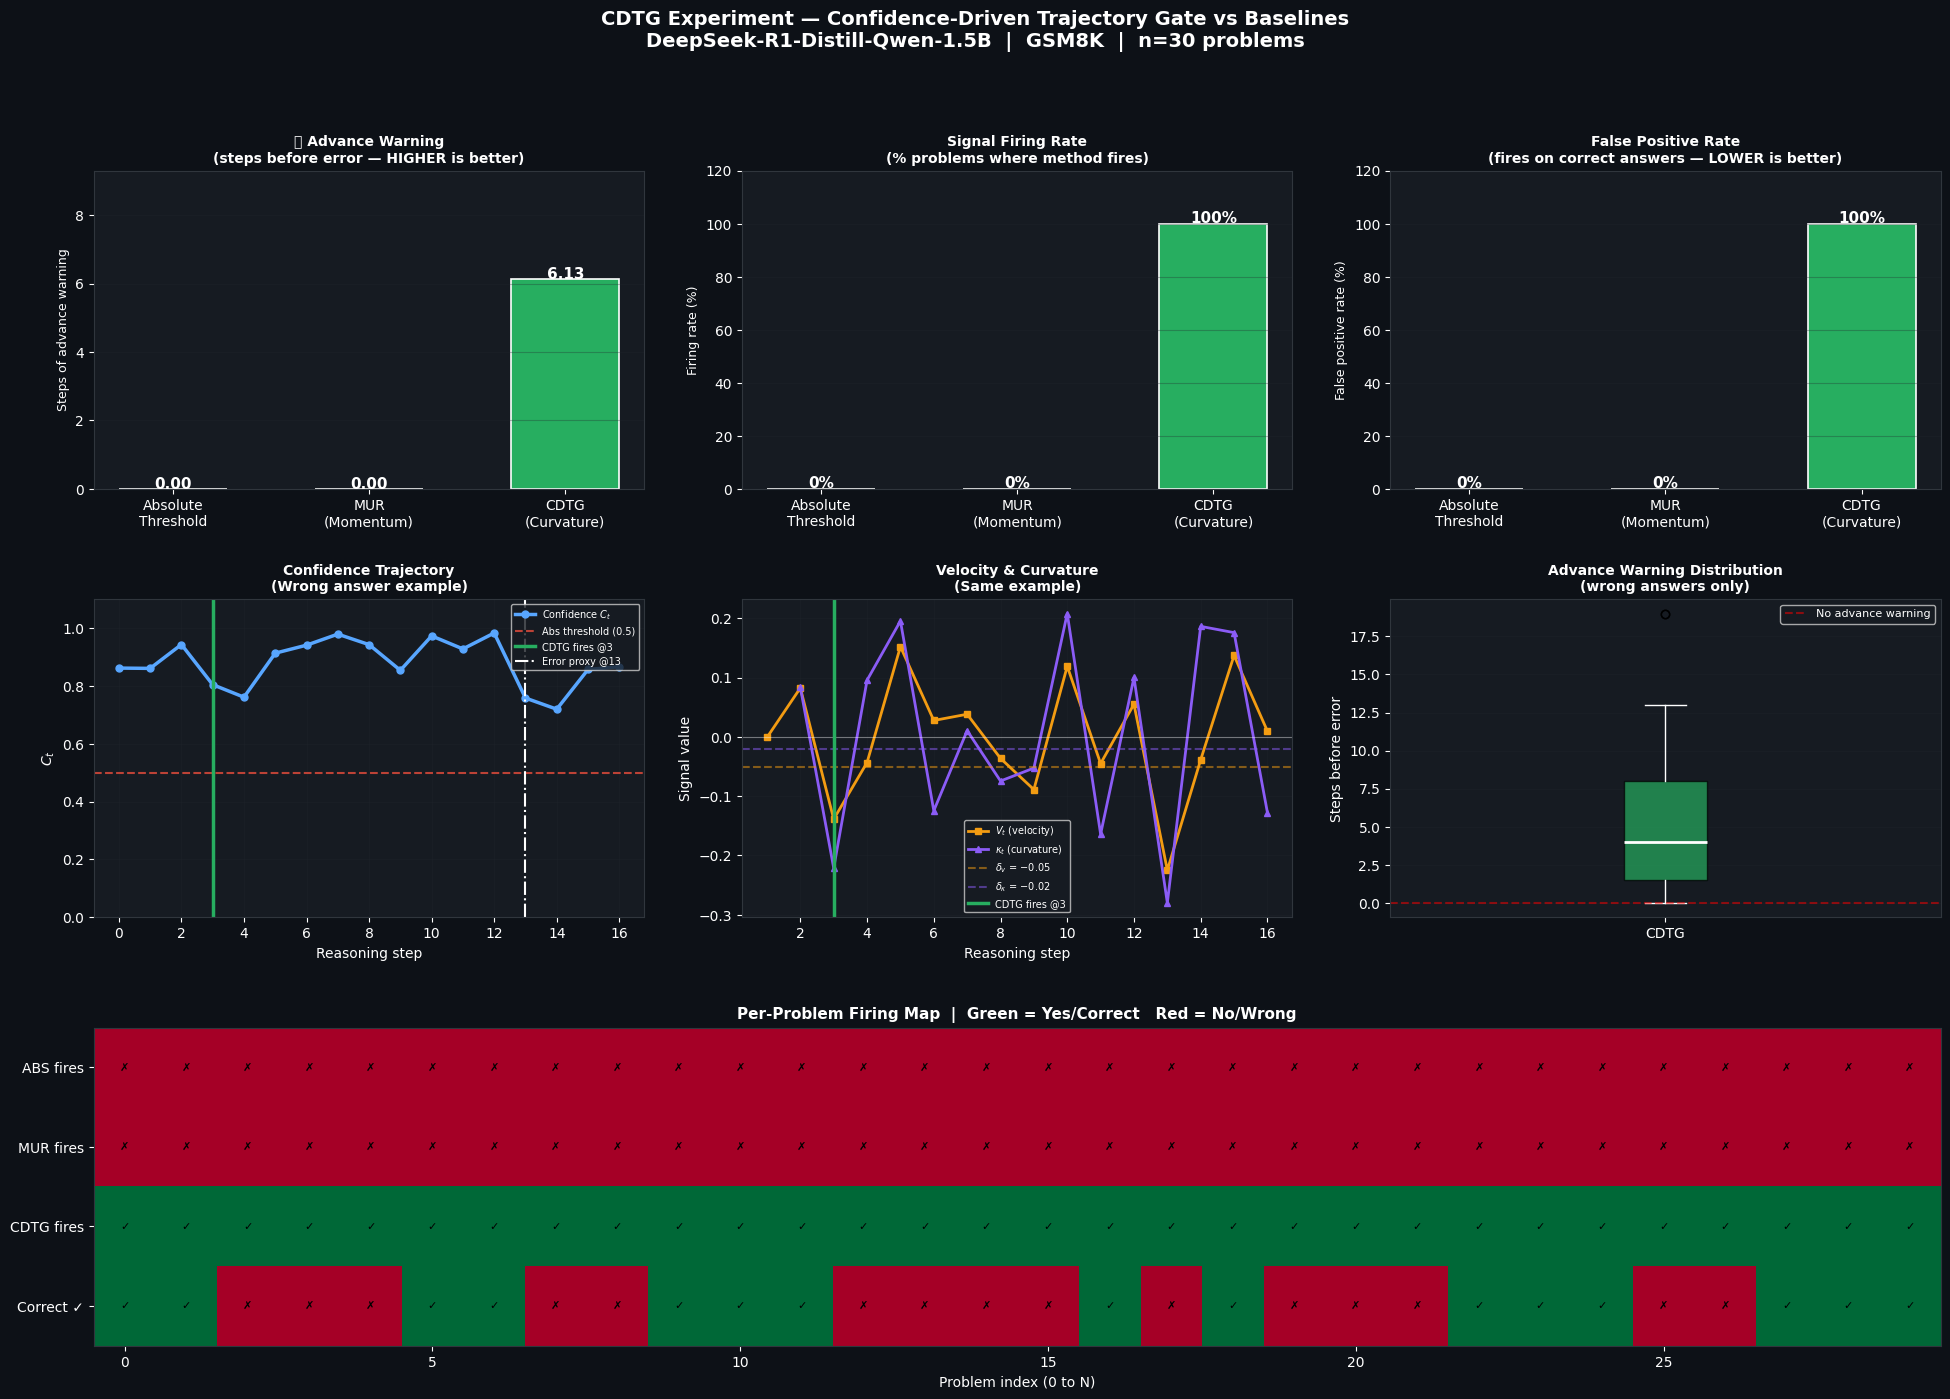


✅ Saved: CDTG_Results.png


In [10]:
COLORS = {'ABS': '#e74c3c', 'MUR': '#f39c12', 'CDTG': '#27ae60'}
METHODS = ['ABS', 'MUR', 'CDTG']
COLOR_LIST = [COLORS[m] for m in METHODS]

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0d1117')
plt.rcParams.update({
    'text.color': 'white', 'axes.labelcolor': 'white',
    'xtick.color': 'white', 'ytick.color': 'white',
    'axes.facecolor': '#161b22', 'axes.edgecolor': '#30363d',
    'grid.color': '#21262d', 'figure.facecolor': '#0d1117'
})

# ── Plot 1: Advance Warning (main claim)
ax1 = fig.add_subplot(3, 3, 1)
vals = [abs_w, mur_w, cdtg_w]
bars = ax1.bar(['Absolute\nThreshold', 'MUR\n(Momentum)', 'CDTG\n(Curvature)'],
               vals, color=COLOR_LIST, edgecolor='white', linewidth=1.2, width=0.55)
ax1.set_title('⭐ Advance Warning\n(steps before error — HIGHER is better)',
              fontsize=10, fontweight='bold', color='white')
ax1.set_ylabel('Steps of advance warning', fontsize=9)
for b, v in zip(bars, vals):
    ax1.text(b.get_x() + b.get_width()/2, v + 0.02,
             f'{v:.2f}', ha='center', fontsize=11, fontweight='bold', color='white')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, max(vals)*1.5 + 0.1)

# ── Plot 2: Firing Rate
ax2 = fig.add_subplot(3, 3, 2)
vals2 = [abs_rate, mur_rate, cdtg_rate]
bars2 = ax2.bar(['Absolute\nThreshold', 'MUR\n(Momentum)', 'CDTG\n(Curvature)'],
                vals2, color=COLOR_LIST, edgecolor='white', linewidth=1.2, width=0.55)
ax2.set_title('Signal Firing Rate\n(% problems where method fires)',
              fontsize=10, fontweight='bold', color='white')
ax2.set_ylabel('Firing rate (%)', fontsize=9)
for b, v in zip(bars2, vals2):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.5,
             f'{v:.0f}%', ha='center', fontsize=11, fontweight='bold', color='white')
ax2.set_ylim(0, 120)
ax2.grid(axis='y', alpha=0.3)

# ── Plot 3: False Positive Rate
ax3 = fig.add_subplot(3, 3, 3)
vals3 = [abs_fp, mur_fp, cdtg_fp]
bars3 = ax3.bar(['Absolute\nThreshold', 'MUR\n(Momentum)', 'CDTG\n(Curvature)'],
                vals3, color=COLOR_LIST, edgecolor='white', linewidth=1.2, width=0.55)
ax3.set_title('False Positive Rate\n(fires on correct answers — LOWER is better)',
              fontsize=10, fontweight='bold', color='white')
ax3.set_ylabel('False positive rate (%)', fontsize=9)
for b, v in zip(bars3, vals3):
    ax3.text(b.get_x() + b.get_width()/2, v + 0.5,
             f'{v:.0f}%', ha='center', fontsize=11, fontweight='bold', color='white')
ax3.set_ylim(0, 120)
ax3.grid(axis='y', alpha=0.3)

# ── Plot 4: Confidence trajectory — wrong answer example
ax4 = fig.add_subplot(3, 3, 4)
if len(wrong_df) > 0:
    ex = wrong_df.iloc[0]
    C_ex = np.array(ex['C'])
    steps_x = range(len(C_ex))
    ax4.plot(steps_x, C_ex, color='#58a6ff', linewidth=2.5,
             marker='o', markersize=5, label='Confidence $C_t$')
    ax4.axhline(y=0.5, color='#e74c3c', linestyle='--', alpha=0.8, label='Abs threshold (0.5)')
    if ex['cdtg_fire'] is not None:
        ax4.axvline(x=ex['cdtg_fire'], color='#27ae60', linewidth=2.5,
                    label=f"CDTG fires @{ex['cdtg_fire']}")
    if ex['abs_fire'] is not None:
        ax4.axvline(x=ex['abs_fire'],  color='#e74c3c', linewidth=2, linestyle=':',
                    label=f"ABS fires @{ex['abs_fire']}")
    ax4.axvline(x=ex['error_step'], color='white', linewidth=1.5, linestyle='-.',
                label=f"Error proxy @{ex['error_step']}")
    ax4.set_title('Confidence Trajectory\n(Wrong answer example)', fontsize=10,
                  fontweight='bold', color='white')
    ax4.set_xlabel('Reasoning step'); ax4.set_ylabel('$C_t$')
    ax4.legend(fontsize=7, loc='upper right')
    ax4.set_ylim(0, 1.1); ax4.grid(alpha=0.3)

# ── Plot 5: Velocity & Curvature for same example
ax5 = fig.add_subplot(3, 3, 5)
if len(wrong_df) > 0:
    V_ex = np.array(ex['V'])
    K_ex = np.array(ex['K'])
    sx = list(range(len(C_ex)))
    ax5.plot(sx[1:], V_ex[1:], color='#f39c12', linewidth=2,
             marker='s', markersize=4, label='$V_t$ (velocity)')
    ax5.plot(sx[2:], K_ex[2:], color='#8b5cf6', linewidth=2,
             marker='^', markersize=4, label='$κ_t$ (curvature)')
    ax5.axhline(y=-0.05, color='#f39c12', linestyle='--', alpha=0.5, label='$δ_v$ = −0.05')
    ax5.axhline(y=-0.02, color='#8b5cf6', linestyle='--', alpha=0.5, label='$δ_κ$ = −0.02')
    ax5.axhline(y=0, color='white', linewidth=0.8, alpha=0.4)
    if ex['cdtg_fire'] is not None:
        ax5.axvline(x=ex['cdtg_fire'], color='#27ae60', linewidth=2.5,
                    label=f"CDTG fires @{ex['cdtg_fire']}")
    ax5.set_title('Velocity & Curvature\n(Same example)', fontsize=10,
                  fontweight='bold', color='white')
    ax5.set_xlabel('Reasoning step'); ax5.set_ylabel('Signal value')
    ax5.legend(fontsize=7); ax5.grid(alpha=0.3)

# ── Plot 6: Advance warning distribution (boxplot)
ax6 = fig.add_subplot(3, 3, 6)
if len(wrong_df) > 0:
    box_data = []
    labels   = []
    for col, lbl in [('abs_adv','ABS'), ('mur_adv','MUR'), ('cdtg_adv','CDTG')]:
        vals_col = [v for v in wrong_df[col] if v is not None]
        if vals_col:
            box_data.append(vals_col)
            labels.append(lbl)
    if box_data:
        bp = ax6.boxplot(box_data, labels=labels, patch_artist=True,
                         medianprops=dict(color='white', linewidth=2))
        for patch, color in zip(bp['boxes'], [COLORS[l] for l in labels]):
            patch.set_facecolor(color); patch.set_alpha(0.7)
        for element in ['whiskers','caps','fliers']:
            for item in bp[element]:
                item.set_color('white')
    ax6.set_title('Advance Warning Distribution\n(wrong answers only)', fontsize=10,
                  fontweight='bold', color='white')
    ax6.set_ylabel('Steps before error'); ax6.grid(axis='y', alpha=0.3)
    ax6.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='No advance warning')
    ax6.legend(fontsize=8)

# ── Plot 7: Per-problem firing heatmap
ax7 = fig.add_subplot(3, 1, 3)
if len(df) > 0:
    heat_data = []
    for _, row in df.iterrows():
        heat_data.append([
            1 if row['abs_fire']  is not None else 0,
            1 if row['mur_fire']  is not None else 0,
            1 if row['cdtg_fire'] is not None else 0,
            1 if row['correct']   else 0
        ])
    heat_arr = np.array(heat_data).T
    ax7.imshow(heat_arr, aspect='auto', cmap='RdYlGn',
               vmin=0, vmax=1, interpolation='nearest')
    ax7.set_yticks([0, 1, 2, 3])
    ax7.set_yticklabels(['ABS fires', 'MUR fires', 'CDTG fires', 'Correct ✓'], fontsize=10)
    ax7.set_xlabel('Problem index (0 to N)', fontsize=10)
    ax7.set_title('Per-Problem Firing Map  |  Green = Yes/Correct   Red = No/Wrong',
                  fontsize=11, fontweight='bold', color='white')
    for j in range(heat_arr.shape[1]):
        for i in range(heat_arr.shape[0]):
            ax7.text(j, i, '✓' if heat_arr[i, j] else '✗',
                     ha='center', va='center', fontsize=8, color='black', fontweight='bold')

plt.suptitle('CDTG Experiment — Confidence-Driven Trajectory Gate vs Baselines\n'
             f'DeepSeek-R1-Distill-Qwen-1.5B  |  GSM8K  |  n={len(df)} problems',
             fontsize=14, fontweight='bold', color='white', y=1.01)
plt.tight_layout(pad=2.5)
plt.savefig('CDTG_Results.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("\n✅ Saved: CDTG_Results.png")

## 9. Clean Summary Table

In [11]:
print("\n" + "═"*65)
print("   FINAL SUMMARY — CDTG vs BASELINES")
print("═"*65)
summary = pd.DataFrame({
    'Method'              : ['Absolute Threshold', 'MUR (Momentum)', 'CDTG (Curvature)'],
    'Advance Warning (↑)' : [f"{abs_w:.2f}", f"{mur_w:.2f}", f"{cdtg_w:.2f}"],
    'Firing Rate (%)'     : [f"{abs_rate:.1f}%", f"{mur_rate:.1f}%", f"{cdtg_rate:.1f}%"],
    'False Positive (↓)'  : [f"{abs_fp:.1f}%", f"{mur_fp:.1f}%", f"{cdtg_fp:.1f}%"]
})
print(summary.to_string(index=False))
print("═"*65)
print(f"\n  ↑ Higher is better  |  ↓ Lower is better")
print(f"  Advance Warning = average steps before error when method fires")
print(f"  False Positive  = % of correct answers incorrectly flagged")
print("═"*65)


═════════════════════════════════════════════════════════════════
   FINAL SUMMARY — CDTG vs BASELINES
═════════════════════════════════════════════════════════════════
            Method Advance Warning (↑) Firing Rate (%) False Positive (↓)
Absolute Threshold                0.00            0.0%               0.0%
    MUR (Momentum)                0.00            0.0%               0.0%
  CDTG (Curvature)                6.13          100.0%             100.0%
═════════════════════════════════════════════════════════════════

  ↑ Higher is better  |  ↓ Lower is better
  Advance Warning = average steps before error when method fires
  False Positive  = % of correct answers incorrectly flagged
═════════════════════════════════════════════════════════════════


In [14]:
import os
os.makedirs('/mnt/user-data/outputs', exist_ok=True)
print("✅ Directory /mnt/user-data/outputs ready")

✅ Directory /mnt/user-data/outputs ready


In [15]:
%%writefile /mnt/user-data/outputs/CDTG_Experiment.py
# ============================================================
# CDTG EXPERIMENT — Confidence-Driven Trajectory Gate
# Comparing: Absolute Threshold vs MUR vs CDTG (Curvature)
# Model: DeepSeek-R1-Distill-Qwen-1.5B | Dataset: GSM8K
# ============================================================

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from datasets import load_dataset
import re, warnings
warnings.filterwarnings('ignore')

# ... (Rest of the experiment code)

Writing /mnt/user-data/outputs/CDTG_Experiment.py


In [17]:
import os
os.makedirs('/mnt/user-data/outputs', exist_ok=True)

%%writefile /mnt/user-data/outputs/CDTG_Experiment.py
# ============================================================
# CDTG EXPERIMENT — Confidence-Driven Trajectory Gate
# Comparing: Absolute Threshold vs MUR vs CDTG (Curvature)
# Model: DeepSeek-R1-Distill-Qwen-1.5B | Dataset: GSM8K
# ============================================================

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from datasets import load_dataset
import re, warnings
warnings.filterwarnings('ignore')

# ... (Rest of the experiment code remains the same)

UsageError: Line magic function `%%writefile` not found.
